In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [4]:
df = pd.read_csv("../data/synthetic_data.csv")

print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

df.head()

Shape: (5500, 5)

Missing values:
 typing_speed    0
mouse_speed     0
click_rate      0
session_time    0
label           0
dtype: int64

Duplicates: 0


,typing_speed,mouse_speed,click_rate,session_time,label
0,209.934283,93.643605,4.321505,292.828839,0
1,197.234714,93.198788,4.694501,298.367205,0
2,212.953771,73.065352,4.402619,303.214744,0
3,230.460597,95.048647,5.110418,347.343073,0
4,195.316933,110.992436,6.197179,262.639135,0


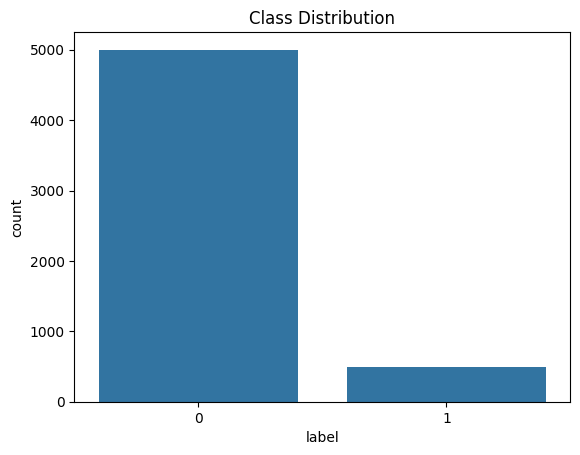

Class Ratio:
 label
0    0.909091
1    0.090909
Name: proportion, dtype: float64


In [5]:
sns.countplot(x="label", data=df)
plt.title("Class Distribution")
plt.show()

imbalance_ratio = df["label"].value_counts(normalize=True)
print("Class Ratio:\n", imbalance_ratio)

## Here the dataset is highly imbalanced, which aligns with real-world fraud detection scenarios

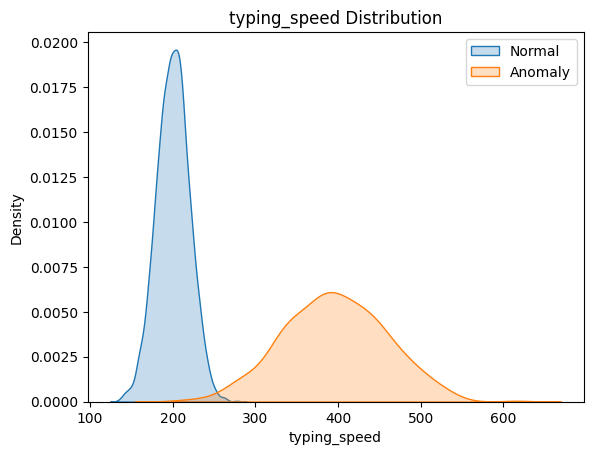

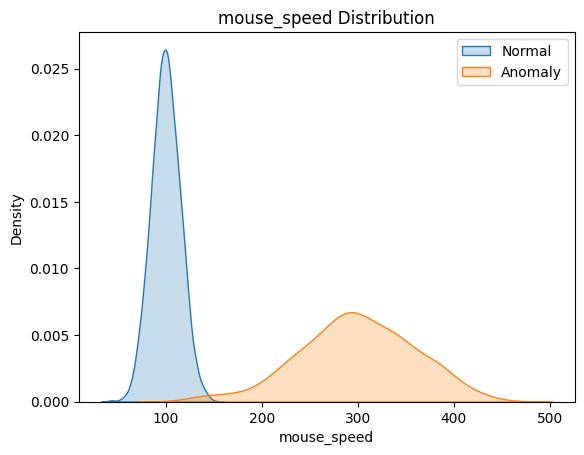

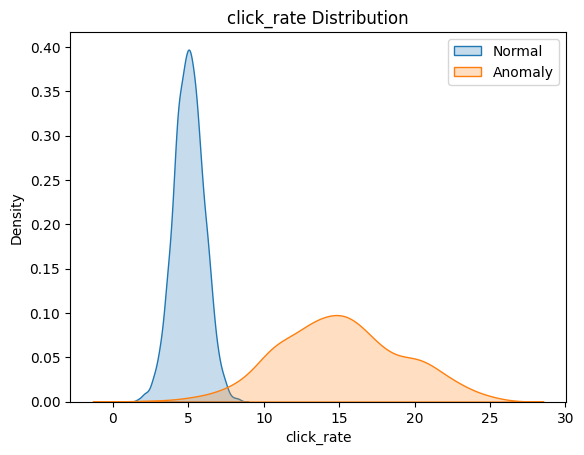

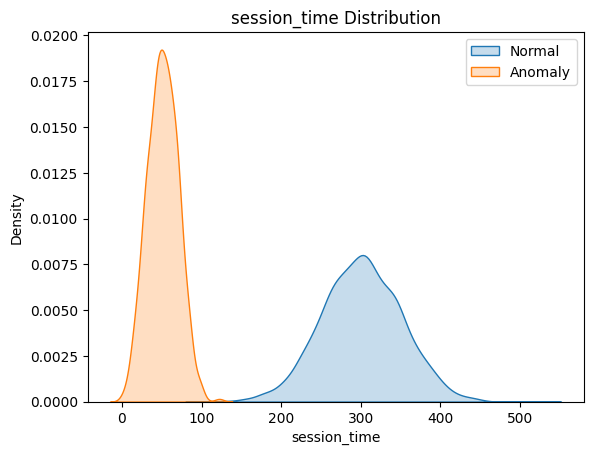

In [6]:
features = ["typing_speed", "mouse_speed", "click_rate", "session_time"]

for col in features:
    plt.figure()
    sns.kdeplot(df[df["label"]==0][col], label="Normal", fill=True)
    sns.kdeplot(df[df["label"]==1][col], label="Anomaly", fill=True)
    plt.title(f"{col} Distribution")
    plt.legend()
    plt.show()

## Showing decision boundary intuition

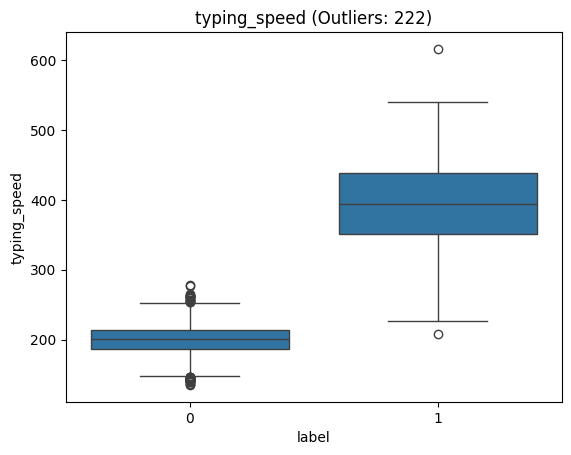

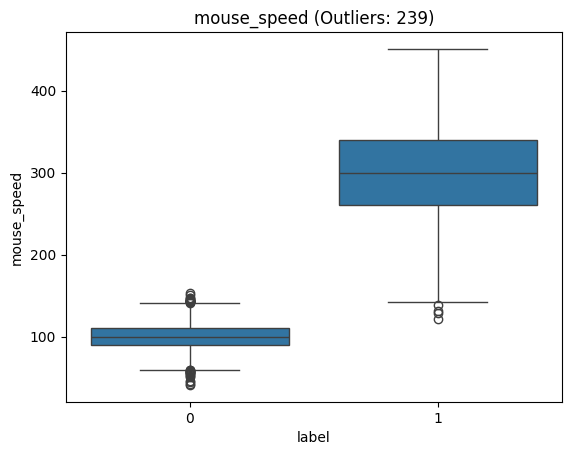

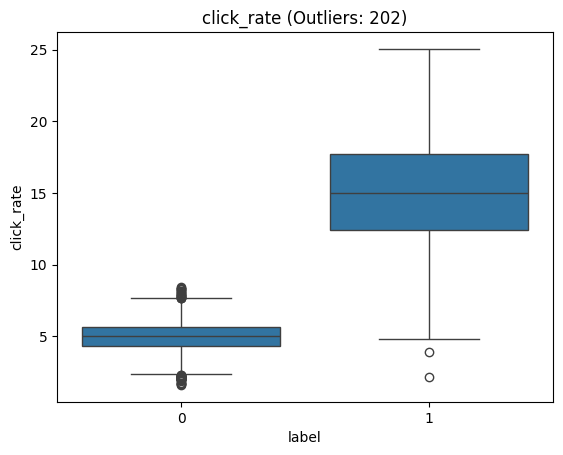

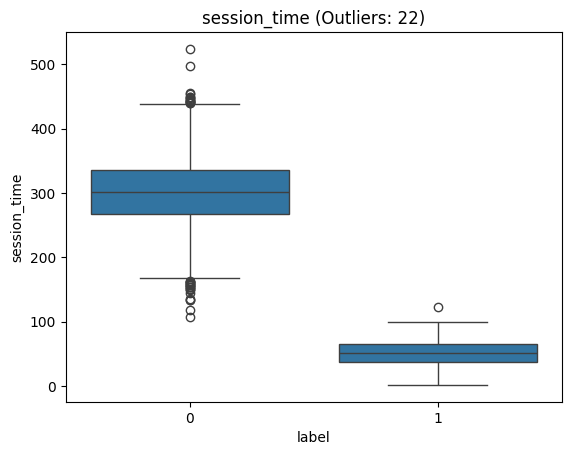

In [7]:
for col in features:
    z = np.abs(stats.zscore(df[col]))
    outliers = (z > 3).sum()
    
    sns.boxplot(x="label", y=col, data=df)
    plt.title(f"{col} (Outliers: {outliers})")
    plt.show()

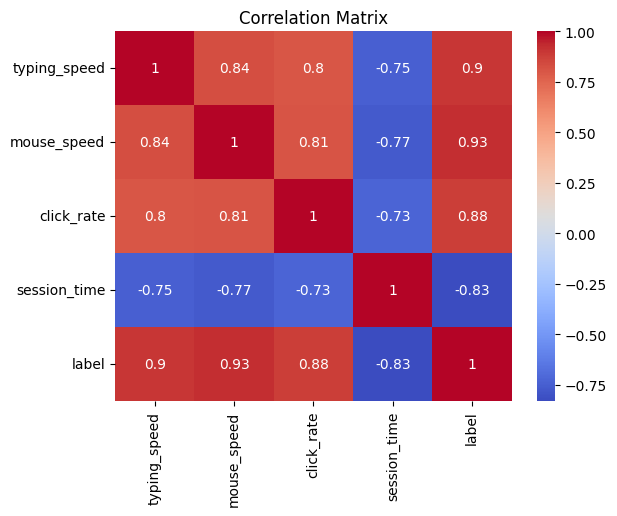

In [8]:
corr = df.corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [9]:
df["typing_variance"] = df["typing_speed"].rolling(5).std().fillna(0)
df["click_diff"] = df["click_rate"].diff().fillna(0)
df["session_intensity"] = df["click_rate"] / (df["session_time"] + 1)

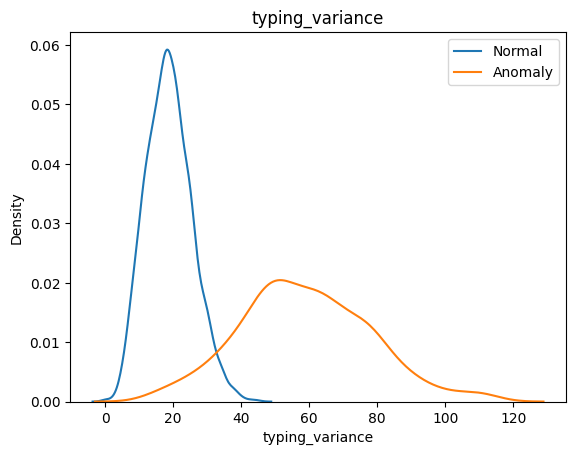

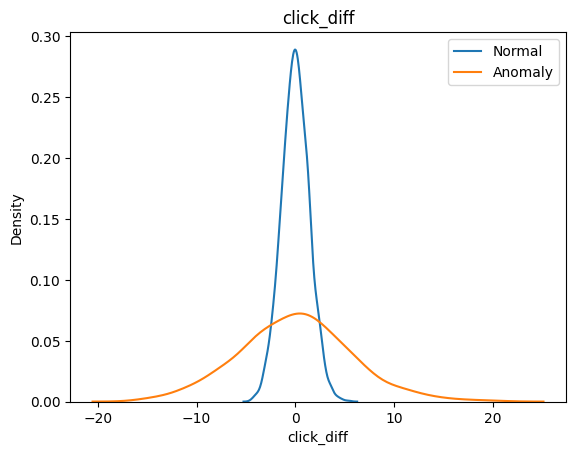

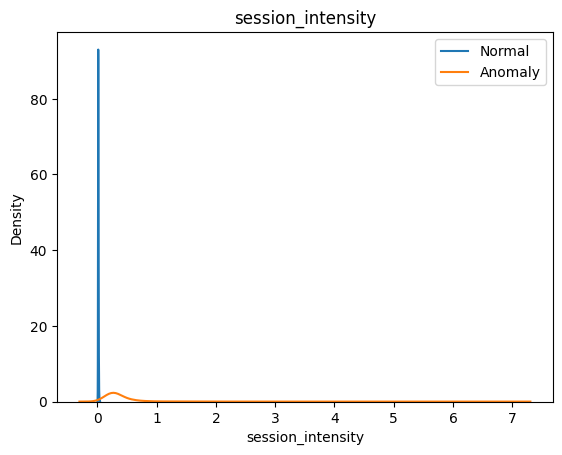

In [10]:
engineered = ["typing_variance", "click_diff", "session_intensity"]

for col in engineered:
    sns.kdeplot(df[df["label"]==0][col], label="Normal")
    sns.kdeplot(df[df["label"]==1][col], label="Anomaly")
    plt.title(col)
    plt.legend()
    plt.show()

In [11]:
results = []

for col in features:
    t_stat, t_p = stats.ttest_ind(df[df["label"]==0][col],
                                 df[df["label"]==1][col])
    
    ks_stat, ks_p = stats.ks_2samp(df[df["label"]==0][col],
                                  df[df["label"]==1][col])
    
    results.append([col, t_p, ks_p])

pd.DataFrame(results, columns=["Feature", "T-test p", "KS-test p"])

,Feature,T-test p,KS-test p
0,typing_speed,0.0,2.964394e-323
1,mouse_speed,0.0,2.964394e-323
2,click_rate,0.0,6.916919e-323
3,session_time,0.0,4.940656e-324


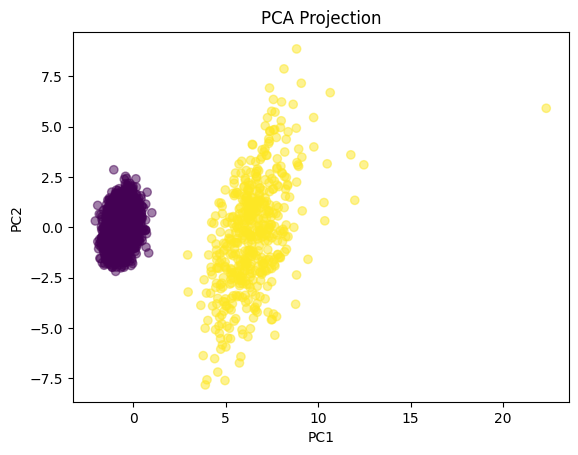

Explained Variance: [0.64582361 0.15698675]


In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.drop("label", axis=1))

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=df["label"], alpha=0.5)
plt.title("PCA Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

print("Explained Variance:", pca.explained_variance_ratio_)

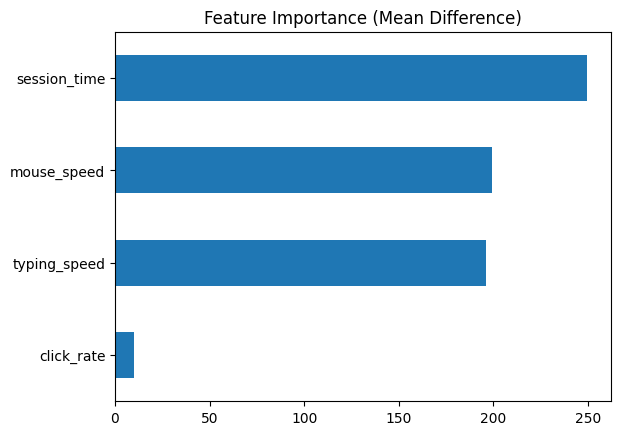

In [13]:
importance = {}

for col in features:
    diff = abs(df[df["label"]==0][col].mean() - df[df["label"]==1][col].mean())
    importance[col] = diff

pd.Series(importance).sort_values().plot(kind="barh")
plt.title("Feature Importance (Mean Difference)")
plt.show()

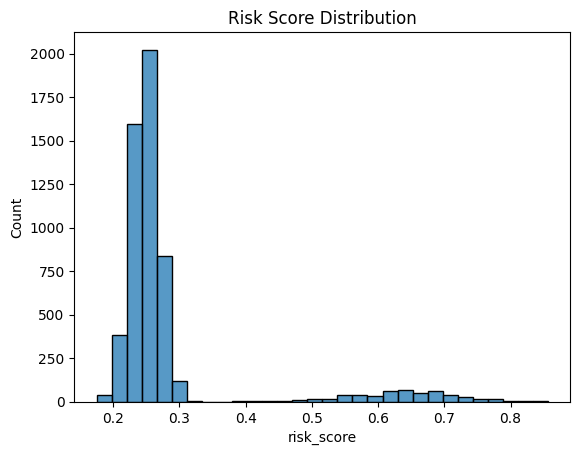

In [14]:
df["risk_score"] = (
    df["typing_speed"]/df["typing_speed"].max() +
    df["mouse_speed"]/df["mouse_speed"].max() +
    df["click_rate"]/df["click_rate"].max()
)/3

sns.histplot(df["risk_score"], bins=30)
plt.title("Risk Score Distribution")
plt.show()

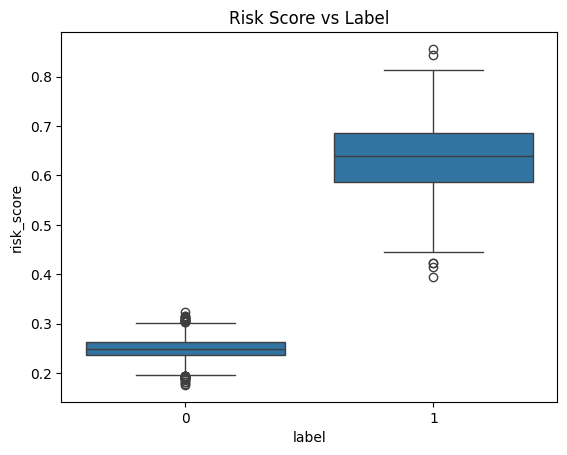

In [15]:
sns.boxplot(x="label", y="risk_score", data=df)
plt.title("Risk Score vs Label")
plt.show()

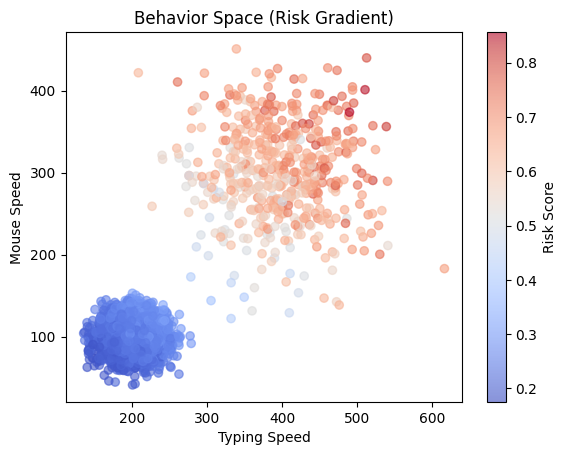

In [16]:
plt.scatter(df["typing_speed"], df["mouse_speed"],
            c=df["risk_score"], cmap="coolwarm", alpha=0.6)

plt.colorbar(label="Risk Score")
plt.title("Behavior Space (Risk Gradient)")
plt.xlabel("Typing Speed")
plt.ylabel("Mouse Speed")
plt.show()

## Key Insights

- Behavioral features strongly differentiate normal vs anomalous users  
- Anomalies exhibit:
  - High typing speed and mouse velocity
  - Increased click frequency
  - Short session durations  

- Statistical tests confirm all features are significant  

- Engineered features improve signal separation  

- PCA reveals clear clustering patterns  

- Risk score aligns with anomaly behavior → usable in production  

## Modeling Justification

- Data is imbalanced → anomaly detection preferred  
- Features show strong separability → Isolation Forest / Autoencoder suitable  
- Temporal features justify sequence models (LSTM)  

## Business Impact

- Enables real-time fraud detection  
- Improves user authentication systems  
- Reduces false positives via behavioral profiling  